In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp
from scipy.optimize import curve_fit, minimize

In [2]:
params = {'legend.fontsize': 'x-large',
          'axes.labelsize': 'x-large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large',
          'ytick.labelsize': 'x-large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [3]:
min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

tiles = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/himalayas/tiles-himalayas.fits'))
mask = tiles['SURVEY']=='sv1'
mask &= (tiles['FAPRGRM']=='lrgqso') | (tiles['FAPRGRM']=='lrgqso2')
mask &= tiles['LRG_EFFTIME_DARK']>2000.
tiles = tiles[mask]
print(len(tiles))

lrg = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_basic.fits'))
pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_pz_new.fits', columns=['Z_PHOT_MEDIAN', 'Z_PHOT_L68', 'Z_PHOT_U68']))
lrgmask = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_lrgmask_v1.1.fits.gz'))
pixel = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_pixel.fits'))
lrg = hstack([lrg, pz, lrgmask, pixel], join_type='exact')
print(len(lrg))

target_bit = 6  # LRG_SV_IR
fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/zcatalog/ztile-sv1-dark-cumulative.fits'
cat = Table(fitsio.read(fn, columns=['SV1_DESI_TARGET']))
idx = np.where(cat['SV1_DESI_TARGET'] & 2**target_bit > 0)[0]
cat = Table(fitsio.read(fn, rows=idx))
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select QSO+LRG tiles
mask = np.in1d(cat['TILEID'], tiles['TILEID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select objects in the extended sample
mask = np.in1d(cat['TARGETID'], lrg['TARGETID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

cat.rename_columns(['TARGET_RA', 'TARGET_DEC'], ['RA', 'DEC'])

# cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'pz_bin', 'weight', 'lrg_mask']], keys='TARGETID')
cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'Z_PHOT_MEDIAN', 'lrg_mask']], keys='TARGETID')
# cat.rename_column('weight', 'imaging_weight')
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 2000.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# exclude QSO targets
mask = ~((cat["SV1_DESI_TARGET"] & (2**2))!=0)
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]
print(len(cat))

# Remove objects classified as QSOs
mask = cat['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as STARs
mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplicated objects
print(len(cat), len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])))

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_himalayas_20230106.txt', dtype=int)
print(len(bad_fibers))
# bad fibers identified from redshift distributions (https://github.com/desihub/desispec/issues/1946)
additional_bad_fibers = [466, 1008, 1098, 1219, 1251, 2675, 2676, 2677, 2678, 2679, 2680, 3994, 3995, 4349, 4720, 2250, 2251, 2252, 2253, 3038]
bad_fibers = np.unique(np.concatenate([bad_fibers, additional_bad_fibers]))
print(len(bad_fibers))
print(bad_fibers)
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Martin's EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()
print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))

38
35354635
47954 47695
42069 41968
40849 40749
40849
FIBERSTATUS    6449 34400 0.1578741217655267
No data    0 34400 0.0
LRG mask 31293 3107 0.09031976744186046
Min depth    1020 30273 0.03259514907487297
Remove QSO targets 28944 1329 0.04390050540085225
28944
Remove objects classified as QSOs: 28551 393 0.013577943615257049
Remove objects classified as STARs: 28425 126 0.0044131554061153724
28425 28369
28369 28369
57
66
[ 466  552  651  817 1008 1098 1219 1251 1400 1597 1765 1969 2250 2251
 2252 2253 2259 2260 2261 2267 2271 2316 2575 2628 2636 2654 2663 2675
 2676 2677 2678 2679 2680 2681 2684 2685 2686 2687 2688 2689 3033 3038
 3082 3476 3500 3546 3618 3754 3849 3974 3994 3995 4002 4019 4089 4349
 4507 4613 4621 4624 4720 4733 4748 4788 4957 4977]
Bad fibers 27978 391 0.01378265007578695
NOBS 27109 869 0.9689398813353349
EBV 26468 641 0.023645283854070605
STARDENS 25792 676 0.025540275049115914
0.007211538461538462
Quality 25606 186 0.007211538461538462


In [4]:
print(len(cat))
# cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['qf'] = np.array(cat['q'], dtype=float)

25792


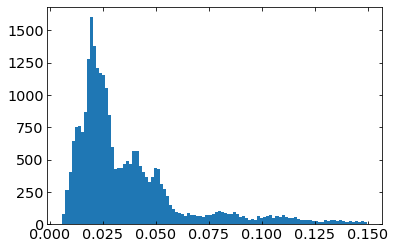

In [5]:
plt.hist(cat['EBV'], 100);

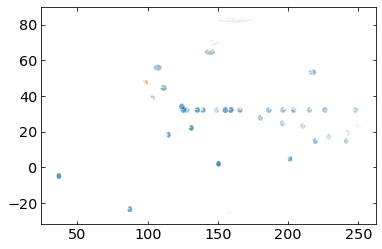

In [6]:
mask = cat['EBV']<0.1
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=0.1, alpha=0.1)
plt.plot(cat['RA'][~mask], cat['DEC'][~mask], '.', ms=0.1, alpha=0.1)
plt.show()

In [7]:
mask = cat['EBV']<0.1
print(np.sum(mask)/len(mask))
cat = cat[mask]

0.9504497518610422


In [8]:
# Remove objects classified as QSOs
mask = cat['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

Remove objects classified as QSOs 24514 0 0.0


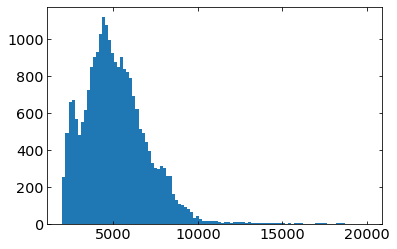

In [9]:
plt.hist(cat['EFFTIME_LRG'][cat['EFFTIME_LRG']<2e4], 100);

In [10]:
# mask = cat['EFFTIME_LRG']>500
mask &= cat['EFFTIME_LRG']<15000
print(np.sum(mask)/len(mask))
cat = cat[mask]
print(len(cat))

mask = cat['zfibermag']>18.
mask &= cat['zfibermag']<22.
cat = cat[mask]
print(len(cat))

0.98947540181121
24256
24251


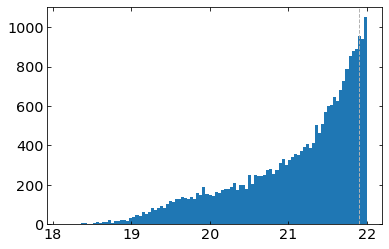

In [11]:
plt.hist(cat['zfibermag'], 100)
plt.axvline(21.9, ls='--', color='0.7', lw=1)
plt.show()

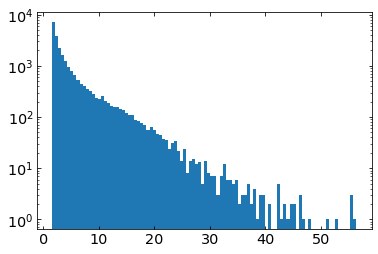

In [12]:
plt.hist(cat['FIBERFLUX_Z_EC'], 100, log=True);

In [13]:
print(np.sum((~cat['q'])), np.sum((~cat['q']))/len((~cat['q'])))
# mask = (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
# print(np.sum((~cat['q']) & mask), np.sum((~cat['q']) & mask)/np.sum(mask))

153 0.006309018184817121


-------

203.38412


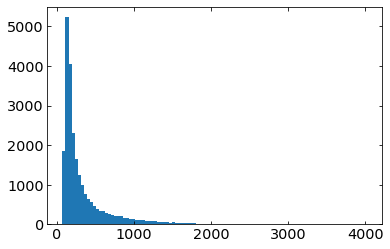

In [14]:
sn = cat['FIBERFLUX_Z_EC']*np.sqrt(cat['EFFTIME_LRG'])
print(np.median(sn))
plt.hist(sn, 100);

In [15]:
def cost(q_predict):
    return np.sum((cat['qf']-q_predict)**2)

def wrapper(coeffs):
    q_predict = 1-failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)
    return cost(q_predict)

# def failure_rate(flux, efftime, a, b):
#     sn = flux * np.sqrt(efftime)
#     return np.clip(np.exp(-(sn+a)/b), 0, 1)
# res = minimize(wrapper, [0, 10.], bounds=((-200, 200), (0, 100)),
#                method='Powell', tol=1e-6)

# Add 1/flux term
def failure_rate(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1)+a2/flux, 0, 1)

res = minimize(wrapper, [-0.09, 3., 0.02], bounds=((-1., 0.), (0, 100), (0., 1)),
               method='Powell', tol=1e-9)

# # Include minimal failure rate
# def failure_rate(flux, efftime, a, b, c):
#     sn = flux * np.sqrt(efftime)
#     return np.clip(np.exp(-(sn+a)/b)-c, 0, 1)
# res = minimize(wrapper, [0, 10., 0.001], bounds=((-200, 200), (0, 100), (0, 0.01)),
#                method='Powell', tol=1e-6)

# # Include sky contribution
# def failure_rate(flux, efftime, a, b, c):
#     sn = flux / np.sqrt(flux + c) * np.sqrt(efftime)
#     return np.clip(np.exp(-(sn+a)/b), 0, 1)
# res = minimize(wrapper, [-1.16346025e-01, 2.3,  10],
#                method='Powell', tol=1e-6)

print(res)
coeffs = res.x
print()
print(coeffs)
print(wrapper(coeffs))

   direc: array([[ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 1.92837060e-02, -1.57074994e+00, -1.55706156e-03],
       [ 5.01280383e-04, -5.24079557e-02, -6.10732038e-05]])
     fun: 150.68852582592314
 message: 'Optimization terminated successfully.'
    nfev: 1360
     nit: 10
  status: 0
 success: True
       x: array([-0.05147332,  0.86560286,  0.01410814])

[-0.05147332  0.86560286  0.01410814]
150.68852582592314


In [16]:
coeffs = [-0.05147332, 0.86560286, 0.01410814]

In [17]:
def failure_rate_sn_term(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1), 0, 1)

def failure_rate_flux_term(flux, efftime, a0, a1, a2):
    return np.clip(a2/flux, 0, 1)

In [18]:
fail_prob = failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)
fail_prob_sn_term = failure_rate_sn_term(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)
fail_prob_flux_term = failure_rate_flux_term(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)

cat['success_prob'] = 1-fail_prob
print(np.sum(~cat['q']), np.sum(1-cat['success_prob']))
print(np.sum(~cat['q'])/np.sum(1-cat['success_prob']))

153 167.57816
0.9130068267397241


In [19]:
print(np.sum(fail_prob), np.sum(fail_prob_sn_term)+np.sum(fail_prob_flux_term), np.sum(fail_prob_sn_term), np.sum(fail_prob_flux_term))

167.57816 167.57816 51.51074 116.06741


Failure rate at zfiber=21.9:
0.0071884208032039374


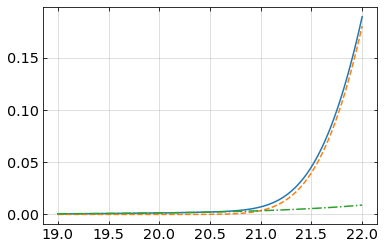

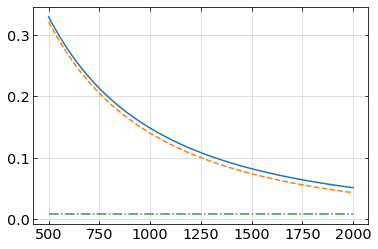

In [30]:
zfiber = 21.
flux = 10**(-0.4*(zfiber-22.5))
efftime = 1000.
print('Failure rate at zfiber=21.9:')
print(failure_rate(flux, efftime, *coeffs))

zfiber = np.linspace(19, 22, 100)
flux = 10**(-0.4*(zfiber-22.5))
efftime = np.full(len(zfiber), 1000.)
plt.plot(zfiber, failure_rate(flux, efftime, *coeffs))
plt.plot(zfiber, failure_rate_sn_term(flux, efftime, *coeffs), '--')
plt.plot(zfiber, failure_rate_flux_term(flux, efftime, *coeffs), '-.')
plt.grid(alpha=0.5)
plt.show()

efftime = np.linspace(500, 2000, 100)
zfiber = np.full(len(efftime), 21.9)
flux = 10**(-0.4*(zfiber-22.5))
plt.plot(efftime, failure_rate(flux, efftime, *coeffs))
plt.plot(efftime, failure_rate_sn_term(flux, efftime, *coeffs), '--')
plt.plot(efftime, failure_rate_flux_term(flux, efftime, *coeffs), '-.')
plt.grid(alpha=0.5)
plt.show()

Failure rate at zfiber=21.9:
0.1485455322406725


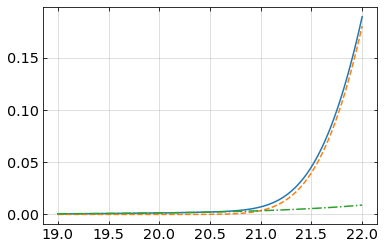

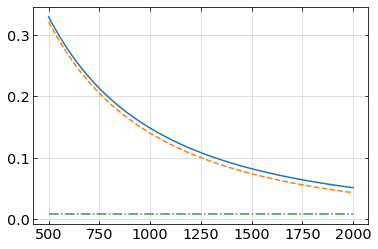

In [20]:
zfiber = 21.9
flux = 10**(-0.4*(zfiber-22.5))
efftime = 1000.
print('Failure rate at zfiber=21.9:')
print(failure_rate(flux, efftime, *coeffs))

zfiber = np.linspace(19, 22, 100)
flux = 10**(-0.4*(zfiber-22.5))
efftime = np.full(len(zfiber), 1000.)
plt.plot(zfiber, failure_rate(flux, efftime, *coeffs))
plt.plot(zfiber, failure_rate_sn_term(flux, efftime, *coeffs), '--')
plt.plot(zfiber, failure_rate_flux_term(flux, efftime, *coeffs), '-.')
plt.grid(alpha=0.5)
plt.show()

efftime = np.linspace(500, 2000, 100)
zfiber = np.full(len(efftime), 21.9)
flux = 10**(-0.4*(zfiber-22.5))
plt.plot(efftime, failure_rate(flux, efftime, *coeffs))
plt.plot(efftime, failure_rate_sn_term(flux, efftime, *coeffs), '--')
plt.plot(efftime, failure_rate_flux_term(flux, efftime, *coeffs), '-.')
plt.grid(alpha=0.5)
plt.show()

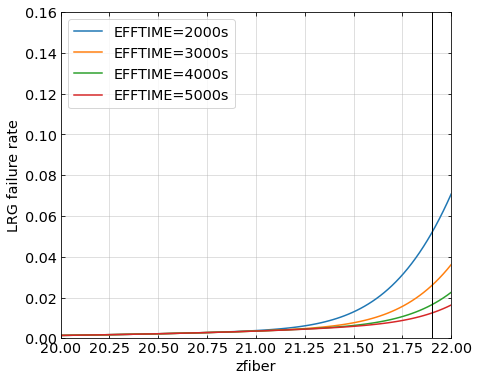

In [21]:
zfiber = 21.9
flux = 10**(-0.4*(zfiber-22.5))
efftimes = [2000, 3000, 4000, 5000]

zfiber = np.linspace(20., 22., 100)
flux = 10**(-0.4*(zfiber-22.5))
plt.figure(figsize=(7, 6))
for efftime in efftimes:
    efftime = np.full(len(zfiber), efftime)
    plt.plot(zfiber, failure_rate(flux, efftime, *coeffs), label='EFFTIME={:.0f}s'.format(efftime[0]))
plt.grid(alpha=0.5)
plt.ylabel('LRG failure rate')
plt.xlabel('zfiber')
plt.legend()
plt.axvline(21.9, lw=1, color='k')
plt.axis([20., 22., 0, 0.16])
plt.show()

/tmp/ipykernel_240247/1686406781.py:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


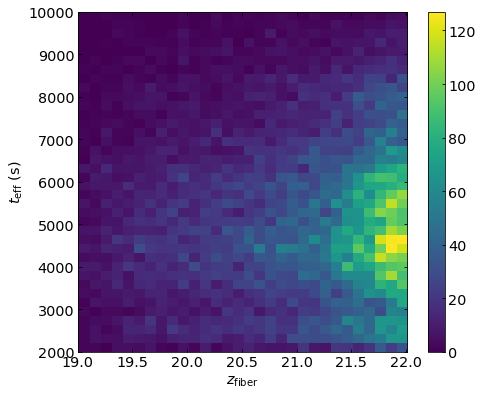

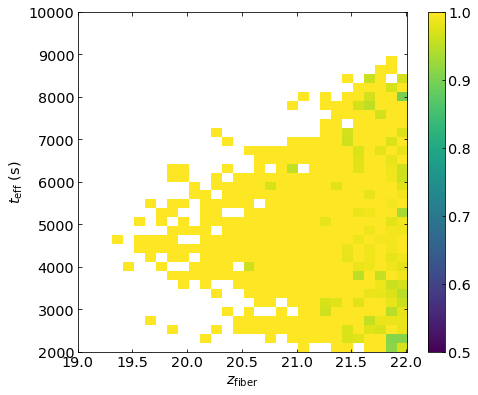

In [22]:
zfiber_bin_edges = np.linspace(18.01, 22.01, 41)
efftime_bin_edges = np.linspace(2000, 10000, 39)

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = cat['q'].copy()
count_2d_good = np.histogram2d(cat['zfibermag'][mask], cat['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d[count_2d_all<=16] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(count_2d_all.T, origin='lower', aspect='auto',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
# ax.axhline(1000., color='0.7', ls='--')
# ax.axvline(21.91, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
# ax.axhline(1000., color='0.7', ls='--')
# ax.axvline(21.91, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

/tmp/ipykernel_240247/385317169.py:2: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


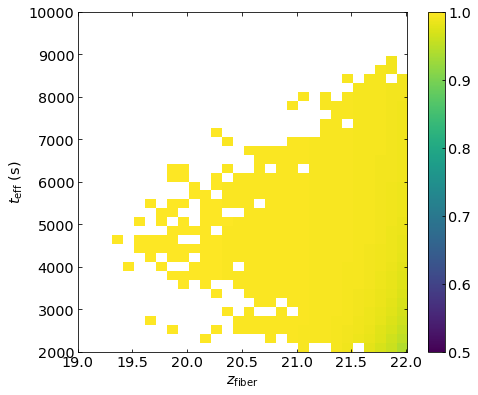

In [23]:
count_2d_good_predict = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=cat['success_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=16] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
# ax.axhline(1000., color='0.7', ls='--')
# ax.axvline(21.91, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

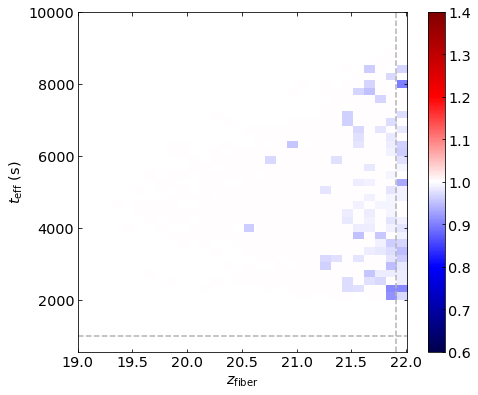

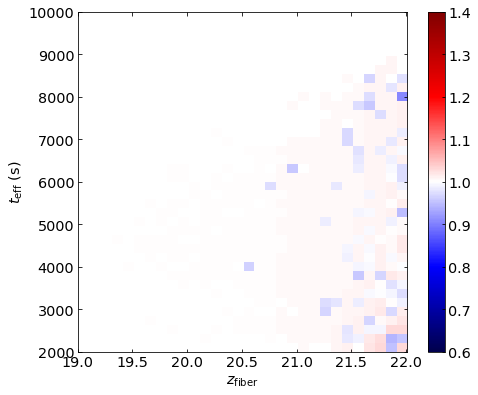

In [24]:
fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow((success_2d).T, origin='lower', aspect='auto', vmin=0.6, vmax=1.4, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.91, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow((success_2d/success_2d_predict).T, origin='lower', aspect='auto', vmin=0.6, vmax=1.4, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
# ax.axhline(1000., color='0.7', ls='--')
# ax.axvline(21.91, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

------

In [25]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

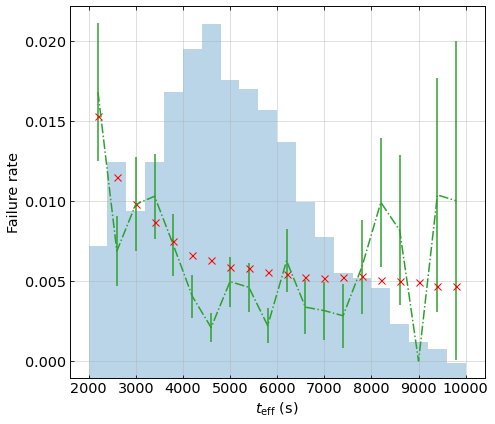

In [26]:
mask = np.full(len(cat), True)
# mask &= (cat['main_lrg'].copy())

area = len(cat)/600

bin_edges = np.linspace(2000, 10000, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (~cat['q'][mask]), bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(cat['EFFTIME_LRG'][mask], 1-cat['success_prob'][mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', color='r', ms=7)
# ax1.xlabel('EFFTIME_LRG')
ax1.set_xlabel('$t_\mathrm{eff}$ (s)')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
# ax1.legend(loc='upper right')
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['EFFTIME_LRG'][mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
# ax2.set_ylabel('a.u.', color=ax2_color)
# ax2.tick_params(axis='y', labelcolor=ax2_color)
ax2.yaxis.set_visible(False)
ax1.set_zorder(1)
ax1.patch.set_visible(False)
# ax1.axis([400, 2100, 0.00, 0.05])
plt.tight_layout()
plt.show()

/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


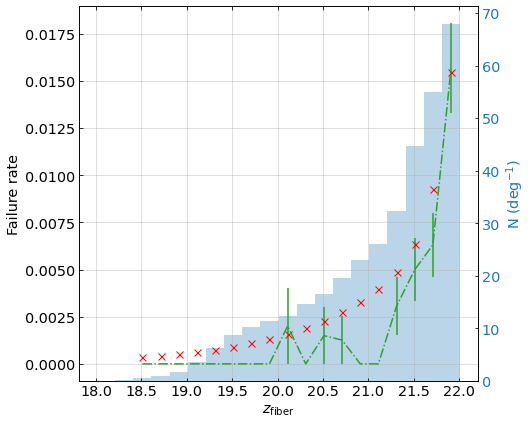

In [27]:
mask = (cat['EFFTIME_LRG']>3000.) & (cat['EFFTIME_LRG']<6000.)
# mask &= cat['main_lrg'].copy()

bin_edges = np.linspace(18.01, 22.01, 21)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

# mask = mask & (cat['survey']=='main')
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~cat['q'])[mask], bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(cat['zfibermag'][mask], (1-cat['success_prob'])[mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7.5, 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', ms=7, color='r')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
# ax1.legend(loc='upper left')
# ax1.title('cat LRGs')
# ax1.axis([18.7, 21.9, 0.00, 0.08])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['zfibermag'][mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()

/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


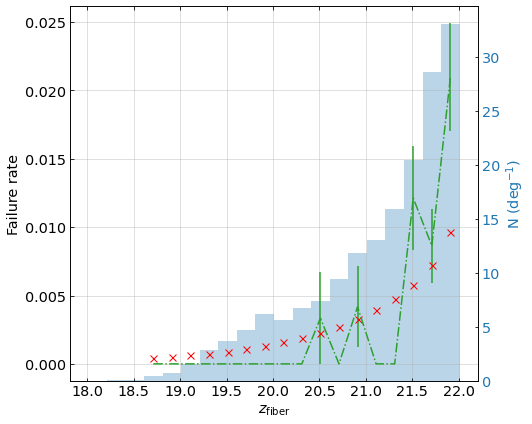

In [28]:
mask = (cat['EFFTIME_LRG']>6000.)
# mask &= cat['main_lrg'].copy()

bin_edges = np.linspace(18.01, 22.01, 21)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

# mask = mask & (cat['survey']=='main')
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~cat['q'])[mask], bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(cat['zfibermag'][mask], (1-cat['success_prob'])[mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7.5, 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', ms=7, color='r')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
# ax1.legend(loc='upper left')
# ax1.title('cat LRGs')
# ax1.axis([18.7, 21.9, 0.00, 0.08])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['zfibermag'][mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()